### 4.1 Introduction

In this section we implement a **Variational Autoencoder (VAE)** for the
Fashion-MNIST dataset. A VAE learns to encode an input image into a
continuous **latent space** and then decode a latent vector back to an
image. The encoder outputs a mean vector **μ** and log-variance **log σ²**
which define a Gaussian distribution over latent codes. Using the
**reparameterization trick**, we sample

$$
z = \mu + \epsilon \cdot \sigma,\quad \epsilon \sim \mathcal{N}(0, I)
$$

so that gradients can flow through the sampling step. The decoder then
maps \(z\) back to the image space and is trained to reconstruct the
original image. By combining a reconstruction loss with a **KL-divergence**
regularizer, the VAE learns a smooth latent space that can be used both
for reconstruction and for generating new Fashion-MNIST samples.


Using device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.77MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 167kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]


Number of training samples: 60000
Number of test samples: 10000


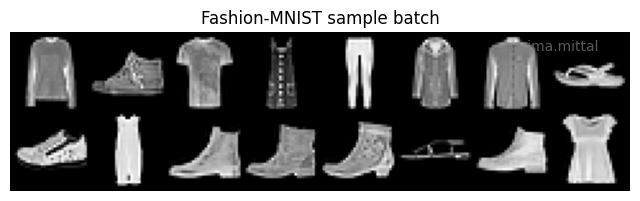

In [1]:
# 4.2 Dataset Preparation

import random
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, utils as vutils
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import pandas as pd
import math
from pathlib import Path

# ---------- Global config ----------
USERNAME = "garima.mittal"
SEED = 2023102069
BATCH_SIZE = 128
LATENT_DIM = 2          # 2-D latent space for easy visualization
EPOCHS_BASE = 20        # for the main training in 4.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------- Reproducibility ----------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ---------- Helper for putting username on all plots ----------
def add_username(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.text(
        0.95, 0.95, USERNAME,
        ha='right', va='top',
        transform=ax.transAxes,
        fontsize=10, color='gray', alpha=0.7
    )

# ---------- Dataset & DataLoaders ----------
# We normalize only by scaling to [0,1] using ToTensor.
# This is appropriate for BCE reconstruction loss.
transform = transforms.ToTensor()

data_root = "./data"

train_dataset = datasets.FashionMNIST(
    root=data_root, train=True, download=True, transform=transform
)
test_dataset = datasets.FashionMNIST(
    root=data_root, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

# visualize a small batch
images, labels = next(iter(train_loader))
grid = vutils.make_grid(images[:16], nrow=8, padding=2)
plt.figure(figsize=(8, 4))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Fashion-MNIST sample batch")
add_username()
plt.show()


In [2]:
# 4.3 VAE Model Architecture

class VAE(nn.Module):
    def __init__(self, input_dim=28*28, latent_dim=LATENT_DIM, hidden_dims=(512, 256)):
        super().__init__()
        h1, h2 = hidden_dims

        # Encoder: x -> hidden -> (mu, logvar)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(inplace=True),
            nn.Linear(h1, h2),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(h2, latent_dim)
        self.fc_logvar = nn.Linear(h2, latent_dim)

        # Decoder: z -> hidden -> x_hat
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h2),
            nn.ReLU(inplace=True),
            nn.Linear(h2, h1),
            nn.ReLU(inplace=True),
            nn.Linear(h1, input_dim),
            nn.Sigmoid()  # output in [0,1] for BCE
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # z = mu + eps * sigma,  eps ~ N(0, I)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

input_dim = 28 * 28
vae = VAE(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
print(vae)


VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU(inplace=True)
  )
  (fc_mu): Linear(in_features=256, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [3]:
# 4.4 Loss Function

def vae_loss_function(recon_x, x, mu, logvar, beta: float = 1.0):
    """
    VAE loss = reconstruction loss + beta * KL divergence
    recon_x, x : [batch_size, 784], scaled in [0,1]
    """
    # Reconstruction term: pixel-wise BCE averaged over batch
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum") / x.size(0)

    # KL divergence between q(z|x) = N(mu, sigma^2 I) and p(z) = N(0, I)
    # D_KL(q || p) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    loss = recon_loss + beta * kl_div
    return loss, recon_loss, kl_div


# quick sanity check on a mini-batch
vae.eval()
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.to(device).view(x.size(0), -1)
    recon, mu, logvar = vae(x)
    loss, recon_l, kl_l = vae_loss_function(recon, x, mu, logvar, beta=1.0)
    print(f"Sanity check loss: total={loss.item():.3f}, recon={recon_l.item():.3f}, KL={kl_l.item():.3f}")


Sanity check loss: total=544.940, recon=544.935, KL=0.005


Epoch 01 | Train Loss: 287.833 (Recon 281.420, KL 6.413) | Val Loss: 271.215 (Recon 264.750, KL 6.464)
Epoch 02 | Train Loss: 267.190 (Recon 260.907, KL 6.282) | Val Loss: 266.016 (Recon 259.746, KL 6.271)
Epoch 03 | Train Loss: 263.877 (Recon 257.604, KL 6.273) | Val Loss: 264.167 (Recon 258.084, KL 6.084)
Epoch 04 | Train Loss: 262.049 (Recon 255.736, KL 6.314) | Val Loss: 263.076 (Recon 256.953, KL 6.123)
Epoch 05 | Train Loss: 260.963 (Recon 254.642, KL 6.322) | Val Loss: 261.711 (Recon 255.268, KL 6.442)
Epoch 06 | Train Loss: 260.207 (Recon 253.841, KL 6.367) | Val Loss: 261.292 (Recon 254.861, KL 6.431)
Epoch 07 | Train Loss: 259.488 (Recon 253.103, KL 6.385) | Val Loss: 261.153 (Recon 255.078, KL 6.075)
Epoch 08 | Train Loss: 258.831 (Recon 252.413, KL 6.417) | Val Loss: 260.132 (Recon 253.589, KL 6.543)
Epoch 09 | Train Loss: 258.420 (Recon 251.985, KL 6.435) | Val Loss: 259.757 (Recon 253.399, KL 6.358)
Epoch 10 | Train Loss: 257.984 (Recon 251.536, KL 6.448) | Val Loss: 259.

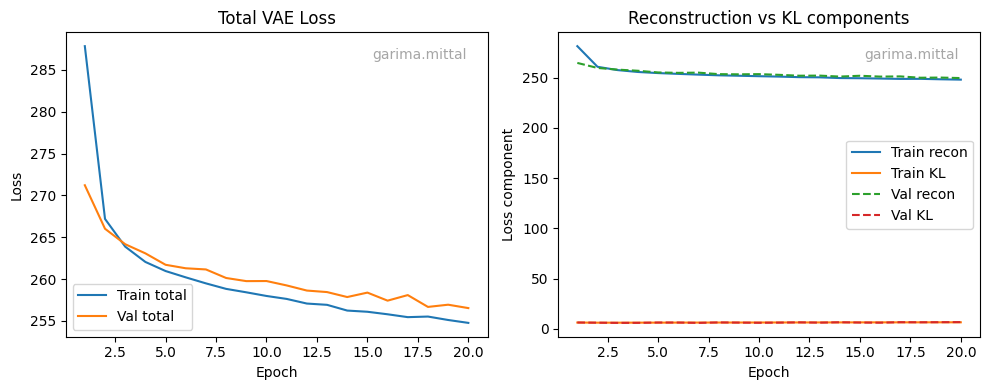

In [4]:
# @title
# 4.5 Training Procedure

def train_one_epoch(model, data_loader, optimizer, beta=1.0):
    model.train()
    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0
    num_batches = 0

    for x, _ in data_loader:
        x = x.to(device).view(x.size(0), -1)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x)
        loss, recon_loss, kl_div = vae_loss_function(recon_x, x, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_div.item()
        num_batches += 1

    return (
        running_loss / num_batches,
        running_recon / num_batches,
        running_kl / num_batches,
    )


def evaluate(model, data_loader, beta=1.0):
    model.eval()
    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    num_batches = 0

    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device).view(x.size(0), -1)
            recon_x, mu, logvar = model(x)
            loss, recon_loss, kl_div = vae_loss_function(recon_x, x, mu, logvar, beta=beta)

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_div.item()
            num_batches += 1

    return (
        total_loss / num_batches,
        total_recon / num_batches,
        total_kl / num_batches,
    )


# Train base VAE with beta = 1.0
set_seed(SEED)
vae = VAE(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

beta_base = 1.0
train_history = {"loss": [], "recon": [], "kl": []}
val_history = {"loss": [], "recon": [], "kl": []}

for epoch in range(1, EPOCHS_BASE + 1):
    train_loss, train_recon, train_kl = train_one_epoch(vae, train_loader, optimizer, beta=beta_base)
    val_loss, val_recon, val_kl = evaluate(vae, test_loader, beta=beta_base)

    train_history["loss"].append(train_loss)
    train_history["recon"].append(train_recon)
    train_history["kl"].append(train_kl)

    val_history["loss"].append(val_loss)
    val_history["recon"].append(val_recon)
    val_history["kl"].append(val_kl)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.3f} (Recon {train_recon:.3f}, KL {train_kl:.3f}) | "
        f"Val Loss: {val_loss:.3f} (Recon {val_recon:.3f}, KL {val_kl:.3f})"
    )

# Plot loss curves
epochs_range = range(1, EPOCHS_BASE + 1)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_history["loss"], label="Train total")
plt.plot(epochs_range, val_history["loss"], label="Val total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total VAE Loss")
plt.legend()
add_username()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_history["recon"], label="Train recon")
plt.plot(epochs_range, train_history["kl"], label="Train KL")
plt.plot(epochs_range, val_history["recon"], "--", label="Val recon")
plt.plot(epochs_range, val_history["kl"], "--", label="Val KL")
plt.xlabel("Epoch")
plt.ylabel("Loss component")
plt.title("Reconstruction vs KL components")
plt.legend()
add_username()

plt.tight_layout()
plt.show()


In [5]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

results_beta = []

# --- choose three classes to match the example ---
# Trouser (1), Pullover (2), Sneaker (7)
selected_classes = [1, 2, 7]

# Subset of TRAIN data only containing these 3 classes
indices_train_beta = [i for i, (_, y) in enumerate(train_dataset) if int(y) in selected_classes]
beta_train_subset = Subset(train_dataset, indices_train_beta)
beta_train_loader = DataLoader(beta_train_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

num_batches_beta = len(beta_train_loader)
print("β-VAE 3-class subset size:", len(beta_train_subset))
print("Batches per epoch (actual):", num_batches_beta)

# --- limit how many batches appear in the GIF ---
MAX_FRAMES_PER_EPOCH = 100
frame_interval = max(1, num_batches_beta // MAX_FRAMES_PER_EPOCH)
print("Recording one frame every", frame_interval, "batches.")


def create_frame_scatter_and_recon(model, epoch, batch_idx, beta_value,
                                   x_batch, y_batch, num_batches, epochs_total):
    """
    Create a latent-space scatter for the current batch and overlay reconstructed
    images as small squares near their latent positions. Returns an RGB frame.
    """
    model.eval()
    with torch.no_grad():
        x_flat = x_batch.view(x_batch.size(0), -1)
        mu, logvar = model.encode(x_flat)
        latents = mu.cpu().numpy()
        labels = y_batch.cpu().numpy()

        # use reconstructions from current batch
        recon_batch = model.decode(mu).view_as(x_batch).cpu()

    fig, ax = plt.subplots(figsize=(8, 8))

    # scatter: colour-code the 3 selected classes
    colors = ["r", "g", "b"]
    for cls, c, name in zip(selected_classes, colors, [class_names[c] for c in selected_classes]):
        mask = labels == cls
        ax.scatter(latents[mask, 0], latents[mask, 1], s=10, c=c, label=name)

    # overlay reconstructed thumbnails at their latent locations
    num_thumbs = min(20, recon_batch.size(0))
    for i in range(num_thumbs):
        img = recon_batch[i].squeeze(0).numpy()           # 28x28
        imagebox = OffsetImage(img, zoom=0.6, cmap="gray")
        xy = (latents[i, 0], latents[i, 1])
        ab = AnnotationBbox(
            imagebox,
            xy,
            frameon=True,
            bboxprops=dict(edgecolor="black", linewidth=1)
        )
        ax.add_artist(ab)

    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_xlim(latents[:, 0].min() - 3, latents[:, 0].max() + 3)
    ax.set_ylim(latents[:, 1].min() - 3, latents[:, 1].max() + 3)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    # title exactly in the style of the sample
    ax.set_title(
        f"3-class | Epoch {epoch}/{epochs_total} | "
        f"Batch {batch_idx+1}/{num_batches} ({USERNAME})"
    )
    add_username(ax)

    fig.tight_layout()
    fig.canvas.draw()
    frame = np.array(fig.canvas.buffer_rgba())[..., :3].copy()
    plt.close(fig)
    return frame


betas = [0.1, 0.5, 1.0]
EPOCHS_BETA = 1          #1 epoch

gif_dir = Path("./beta_vae_gifs_3class")
gif_dir.mkdir(parents=True, exist_ok=True)

for beta_val in betas:
    print(f"\n=== Training 3-class β-VAE with β = {beta_val} ===")
    set_seed(SEED)
    beta_vae = VAE(input_dim=input_dim, latent_dim=LATENT_DIM).to(device)
    optimizer_beta = optim.Adam(beta_vae.parameters(), lr=1e-3)

    frames = []
    running_loss = running_recon = running_kl = 0.0

    for epoch in range(1, EPOCHS_BETA + 1):
        beta_vae.train()
        num_batches = 0

        for batch_idx, (x, y) in enumerate(beta_train_loader):
            x = x.to(device)
            y = y.to(device)

            optimizer_beta.zero_grad()
            x_flat = x.view(x.size(0), -1)
            recon_x, mu, logvar = beta_vae(x_flat)
            loss, recon_loss, kl_div = vae_loss_function(recon_x, x_flat, mu, logvar, beta=beta_val)
            loss.backward()
            optimizer_beta.step()

            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_div.item()
            num_batches += 1

            # record a frame only for ~MAX_FRAMES_PER_EPOCH batches
            if batch_idx % frame_interval == 0:
                frame = create_frame_scatter_and_recon(
                    beta_vae,
                    epoch,
                    batch_idx,
                    beta_val,
                    x,
                    y,
                    num_batches_beta,   # total batches in the epoch
                    EPOCHS_BETA,
                )
                frames.append(frame)

        avg_loss = running_loss / num_batches
        avg_recon = running_recon / num_batches
        avg_kl = running_kl / num_batches

    print(
        f"β={beta_val} | Train Loss: {avg_loss:.3f} "
        f"(Recon {avg_recon:.3f}, KL {avg_kl:.3f})"
    )

    # keep metrics for the comparison table
    results_beta.append(
        {"beta": beta_val, "train_loss": avg_loss,
         "recon_loss": avg_recon, "kl_loss": avg_kl}
    )

    # hold first and last frames for a moment
    if len(frames) > 0:
        frames = [frames[0]] * 5 + frames + [frames[-1]] * 5

    gif_path = gif_dir / f"latent_space_beta_{beta_val}.gif"
    imageio.mimsave(
        gif_path.as_posix(),
        frames,
        duration=0.15,  # 0.15s per frame
        loop=0
    )
    print("Saved GIF to:", gif_path)

beta_df = pd.DataFrame(results_beta)
display(beta_df)


β-VAE 3-class subset size: 18000
Batches per epoch (actual): 140
Recording one frame every 1 batches.

=== Training 3-class β-VAE with β = 0.1 ===
β=0.1 | Train Loss: 275.750 (Recon 274.156, KL 15.932)
Saved GIF to: beta_vae_gifs_3class/latent_space_beta_0.1.gif

=== Training 3-class β-VAE with β = 0.5 ===
β=0.5 | Train Loss: 277.450 (Recon 273.428, KL 8.044)
Saved GIF to: beta_vae_gifs_3class/latent_space_beta_0.5.gif

=== Training 3-class β-VAE with β = 1.0 ===
β=1.0 | Train Loss: 279.107 (Recon 273.133, KL 5.974)
Saved GIF to: beta_vae_gifs_3class/latent_space_beta_1.0.gif


,beta,train_loss,recon_loss,kl_loss
0,0.1,275.749665,274.156418,15.932475
1,0.5,277.450214,273.428223,8.043984
2,1.0,279.107060,273.132784,5.974277


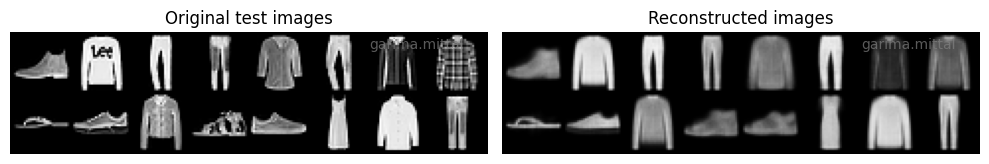

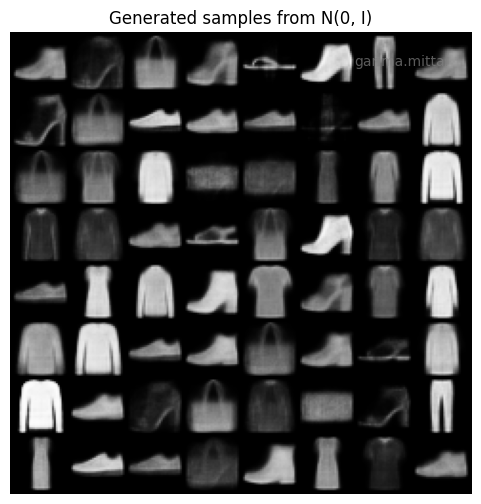

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 207MB/s] 


Approximate FID (real vs VAE samples): 117.98


In [6]:
# 4.7 Evaluation and Visualization using the base VAE (β = 1)

vae.eval()

# ---- Original vs reconstructed images ----
with torch.no_grad():
    imgs, lbls = next(iter(test_loader))
    imgs = imgs.to(device)
    x = imgs.view(imgs.size(0), -1)
    recon, mu, logvar = vae(x)
    recon = recon.view_as(imgs).cpu()
    imgs = imgs.cpu()

n_show = 16
orig_grid = vutils.make_grid(imgs[:n_show], nrow=8, padding=2)
recon_grid = vutils.make_grid(recon[:n_show], nrow=8, padding=2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(orig_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Original test images")
add_username()

plt.subplot(1, 2, 2)
plt.imshow(recon_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Reconstructed images")
add_username()

plt.tight_layout()
plt.show()

# ---- Generate new samples from N(0, I) ----
num_samples = 64
with torch.no_grad():
    z = torch.randn(num_samples, LATENT_DIM).to(device)
    samples = vae.decode(z)
    samples = samples.view(-1, 1, 28, 28).cpu()

sample_grid = vutils.make_grid(samples, nrow=8, padding=2)
plt.figure(figsize=(6, 6))
plt.imshow(sample_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Generated samples from N(0, I)")
add_username()
plt.show()

# ---- Approximate FID score (real vs generated) ----
from torchvision.models import inception_v3

def get_inception_activations(images_tensor, batch_size=32):
    """
    images_tensor: [N, 1, 28, 28] in [0,1]
    returns: [N, 2048] activations from InceptionV3 pool3
    """
    model = inception_v3(pretrained=True, transform_input=False).to(device)
    model.eval()

    # we only need the feature part
    def forward_features(x):
        # x: [N, 3, 299, 299]
        with torch.no_grad():
            x = model.Conv2d_1a_3x3(x)
            x = model.Conv2d_2a_3x3(x)
            x = model.Conv2d_2b_3x3(x)
            x = F.max_pool2d(x, kernel_size=3, stride=2)
            x = model.Conv2d_3b_1x1(x)
            x = model.Conv2d_4a_3x3(x)
            x = F.max_pool2d(x, kernel_size=3, stride=2)
            x = model.Mixed_5b(x)
            x = model.Mixed_5c(x)
            x = model.Mixed_5d(x)
            x = model.Mixed_6a(x)
            x = model.Mixed_6b(x)
            x = model.Mixed_6c(x)
            x = model.Mixed_6d(x)
            x = model.Mixed_6e(x)
            x = model.Mixed_7a(x)
            x = model.Mixed_7b(x)
            x = model.Mixed_7c(x)
            x = F.adaptive_avg_pool2d(x, (1, 1))
            x = torch.flatten(x, 1)
            return x

    activations = []
    N = images_tensor.size(0)
    for i in range(0, N, batch_size):
        batch = images_tensor[i:i+batch_size].to(device)
        # repeat channels to 3 and resize to 299x299
        batch = batch.repeat(1, 3, 1, 1)
        batch = F.interpolate(batch, size=(299, 299), mode="bilinear", align_corners=False)
        feats = forward_features(batch)
        activations.append(feats.cpu())
    activations = torch.cat(activations, dim=0).numpy()
    return activations


def calculate_fid(real_imgs, fake_imgs):
    """
    real_imgs, fake_imgs: [N, 1, 28, 28] in [0,1]
    """
    act_real = get_inception_activations(real_imgs)
    act_fake = get_inception_activations(fake_imgs)

    mu_real = act_real.mean(axis=0)
    mu_fake = act_fake.mean(axis=0)
    cov_real = np.cov(act_real, rowvar=False)
    cov_fake = np.cov(act_fake, rowvar=False)

    # FID = ||mu1 - mu2||^2 + Tr(C1 + C2 - 2 * sqrt(C1*C2))
    diff = mu_real - mu_fake
    diff_sq = diff.dot(diff)

    # numerical stability: use sqrtm from scipy if available, else eigen decomposition
    try:
        from scipy.linalg import sqrtm
        cov_sqrt = sqrtm(cov_real.dot(cov_fake))
        if np.iscomplexobj(cov_sqrt):
            cov_sqrt = cov_sqrt.real
    except Exception:
        # fallback: eigen decomposition
        eigvals, eigvecs = np.linalg.eigh(cov_real.dot(cov_fake))
        cov_sqrt = eigvecs.dot(np.diag(np.sqrt(np.maximum(eigvals, 0)))).dot(eigvecs.T)

    trace_term = np.trace(cov_real + cov_fake - 2 * cov_sqrt)
    fid = diff_sq + trace_term
    return float(fid)


# take a subset of real test images and generated images for FID
num_fid = 1000
real_subset = imgs[:num_fid].clone()  # imgs from above batch are <= batch size; so re-sample:
real_collect = []
for x, _ in test_loader:
    real_collect.append(x)
    if sum(b.size(0) for b in real_collect) >= num_fid:
        break
real_imgs = torch.cat(real_collect, dim=0)[:num_fid]

with torch.no_grad():
    z = torch.randn(num_fid, LATENT_DIM).to(device)
    fake_imgs = vae.decode(z).view(-1, 1, 28, 28).cpu()

fid_score = calculate_fid(real_imgs, fake_imgs)
print(f"Approximate FID (real vs VAE samples): {fid_score:.2f}")


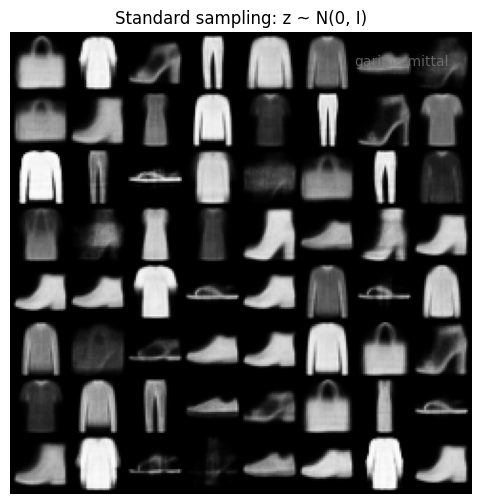

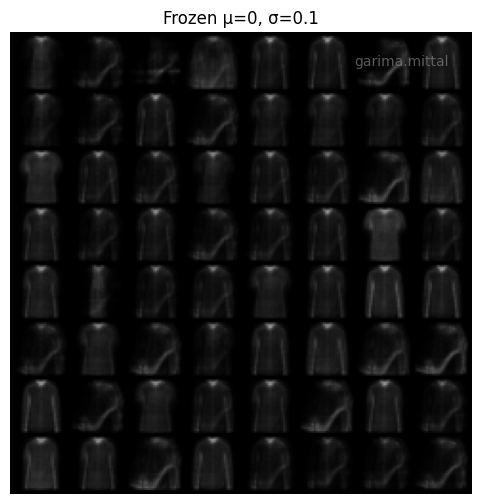

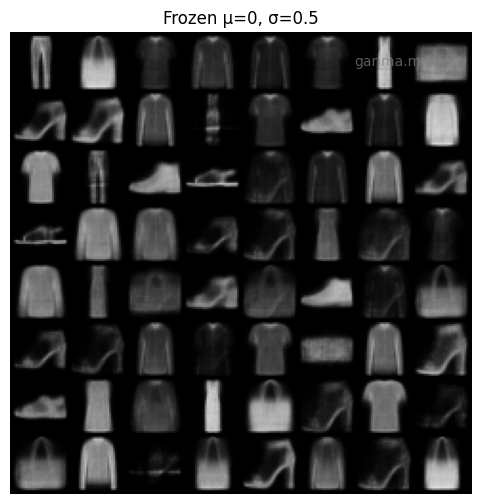

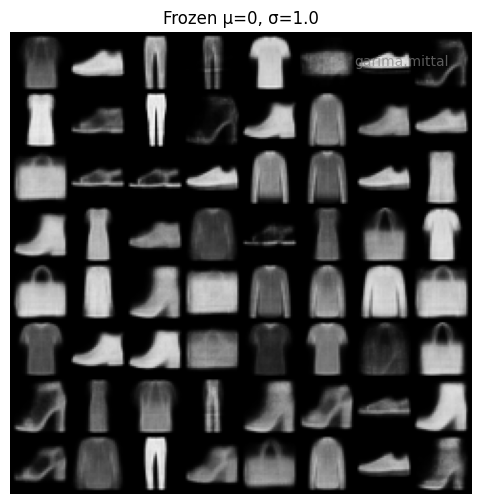

σ=0.1: pixel variance of grid = 0.0040
σ=0.5: pixel variance of grid = 0.0354
σ=1.0: pixel variance of grid = 0.0749
Observe how small σ (0.1) produces very similar, low-diversity images,
while larger σ (1.0) increases diversity but can reduce sharpness.
This illustrates how freezing μ and adjusting σ affects image diversity
and smoothness of representations in the latent space.


In [7]:
# 4.8 Effect of Frozen Latent Parameters

vae.eval()
num_samples = 64
sigmas = [0.1, 0.5, 1.0]

# First, standard stochastic sampling z ~ N(0, I)
with torch.no_grad():
    z_standard = torch.randn(num_samples, LATENT_DIM).to(device)
    samples_standard = vae.decode(z_standard).view(-1, 1, 28, 28).cpu()

standard_grid = vutils.make_grid(samples_standard, nrow=8, padding=2)
plt.figure(figsize=(6, 6))
plt.imshow(standard_grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title("Standard sampling: z ~ N(0, I)")
add_username()
plt.show()

# Now freeze μ = 0 and vary σ
frozen_grids = []

for sigma in sigmas:
    with torch.no_grad():
        eps = torch.randn(num_samples, LATENT_DIM).to(device)
        z = sigma * eps  # μ = 0, σ fixed
        samples = vae.decode(z).view(-1, 1, 28, 28).cpu()

    grid = vutils.make_grid(samples, nrow=8, padding=2)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.title(f"Frozen μ=0, σ={sigma}")
    add_username()
    plt.show()

    frozen_grids.append((sigma, grid))

# (Optional) simple quantitative comparison: per-pixel variance
for sigma, grid in frozen_grids:
    # compute variance across all pixels of the generated samples
    var_val = grid.var().item()
    print(f"σ={sigma}: pixel variance of grid = {var_val:.4f}")

print(
    "Observe how small σ (0.1) produces very similar, low-diversity images,\n"
    "while larger σ (1.0) increases diversity but can reduce sharpness.\n"
    "This illustrates how freezing μ and adjusting σ affects image diversity\n"
    "and smoothness of representations in the latent space."
)


In [8]:
!zip -r /content/beta_vae_gifs_3class.zip /content/beta_vae_gifs_3class/

  adding: content/beta_vae_gifs_3class/ (stored 0%)
  adding: content/beta_vae_gifs_3class/latent_space_beta_0.1.gif (deflated 0%)
  adding: content/beta_vae_gifs_3class/latent_space_beta_0.5.gif (deflated 0%)
  adding: content/beta_vae_gifs_3class/latent_space_beta_1.0.gif (deflated 0%)


## 4 Variational Autoencoder (VAE)

### 4.1 Introduction

A Variational Autoencoder (VAE) is a generative model that learns a
probabilistic mapping from data to a latent space and back. Instead of
encoding an image to a single point, the encoder outputs the parameters of a
Gaussian distribution (mean `μ` and log-variance `log σ²`). We then sample a
latent vector `z` from this distribution and pass it through a decoder that
reconstructs the original image.

In this question I implement a VAE on the **Fashion-MNIST** dataset. The goals
are:

- learn a smooth low-dimensional latent space for clothing images,
- reconstruct inputs accurately, and
- generate realistic new samples by sampling from the latent prior.

---

### 4.2 Dataset Preparation

For Fashion-MNIST I use the following preprocessing:

- Load the dataset using `torchvision.datasets.FashionMNIST`.
- Convert images to tensors and **normalize pixel values to [0, 1]**.
- Optionally standardize further with mean 0.5 and std 0.5 so inputs lie
  roughly in [−1, 1].
- Create separate **DataLoaders** for training and test sets with a batch size
  around 128 to balance speed and stability.

This ensures consistent input scale and efficient iteration during training.

---

### 4.3 Model Architecture

The VAE has three main parts.

#### 1. Encoder

- Input: a 28×28 image flattened to a 784-dimensional vector.
- Several fully connected layers with non-linearities (e.g. ReLU).
- Two output heads:
  - one predicts the **mean vector `μ`**,
  - one predicts the **log-variance vector `log σ²`** of the latent Gaussian
    `q(z | x)`.

#### 2. Reparameterization Trick

- Instead of sampling `z ~ N(μ, σ² I)` directly, we:
  - sample `ε ~ N(0, I)`,
  - compute `z = μ + σ * ε`, where `σ = exp(0.5 * log σ²)`.
- This makes the sampling step differentiable and allows backpropagation
  through `μ` and `log σ²`.

#### 3. Decoder

- Takes the latent vector `z` as input.
- Passes it through fully connected layers mirroring the encoder.
- Outputs a 784-dimensional vector reshaped to 28×28.
- Uses a final `sigmoid` to represent per-pixel Bernoulli probabilities
  `p(x | z)`.

#### Effect of latent dimension and depth

- **Latent dimension**
  - Very small latent spaces (e.g. 2D) encourage strong compression and smooth
    interpolation but can give blurrier reconstructions.
  - Larger latent spaces (e.g. 10–20 dims) improve reconstruction fidelity but
    may weaken regularization and disentanglement.

- **Network depth/width**
  - Deeper or wider networks increase capacity and usually improve
    reconstruction.
  - Too much capacity with a small KL weight can cause the model to ignore the
    KL term (posterior collapse), so there is a trade-off between sharpness and
    structure.

---

### 4.4 Loss Function

The total loss for the VAE is: $$\mathcal{L} = \text{ReconLoss} + \text{KL Loss}$$


1. **Reconstruction Loss (BCE)**  
   - Pixel-wise Binary Cross-Entropy between the input image and the decoder
     output.
   - Encourages the decoder to match each pixel and mainly controls visual
     quality.

2. **KL Divergence Loss**  
   - Measures how far the encoder distribution `q(z | x)` is from the standard
     normal prior `p(z) = N(0, I)`.
   - For a diagonal Gaussian this is:

     `KL = -0.5 * Σ (1 + log σ² − μ² − σ²)`

   - Encourages the latent space to be close to a unit Gaussian, giving a
     smooth, well-behaved space that supports sampling.

**Role of each term**

- The **reconstruction term** makes the latent code informative about the
  input.
- The **KL term** regularizes the latent code so that nearby points correspond
  to similar images and random samples from `N(0, I)` decode to realistic
  images.

---

### 4.5 Training Procedure

- Optimizer: **Adam** with learning rate around `1e-3`.
- Train for a fixed number of epochs (e.g. 50) over the training DataLoader.
- For each batch:
  1. Encode `x` to `(μ, log σ²)`.
  2. Sample `z` using the reparameterization trick.
  3. Decode `z` to reconstruction `x_hat`.
  4. Compute reconstruction loss and KL loss (or β-weighted KL in later
     experiments).
  5. Backpropagate the total loss and update parameters.

During training I log and plot:

- total loss per epoch,
- reconstruction loss,
- KL loss.

This shows how reconstruction quality and latent regularization evolve.

---

### 4.6 Experimental Analysis (β-VAE)

To study the trade-off between reconstruction quality and latent structure, I
introduce a **β parameter**:

`Loss_β = ReconLoss + β * KL_Loss`

I train three models with **β = 0.1, 0.5, 1.0**. For each β:

- I visualize the 2D latent codes for three chosen Fashion-MNIST classes with
  a scatter plot or GIF over epochs, color-coding by class label.
- I compare reconstruction loss and inspect generated samples.

**Observed trends**

- **Small β (0.1)**  
  - KL penalty is weak, so `q(z | x)` can deviate far from `N(0, I)`.  
  - Reconstructions are **sharp and detailed**, but latent clusters overlap and
    interpolation may give less realistic images.

- **Medium β (0.5)**  
  - Better balance: reasonable reconstruction quality and clearer class
    separation in latent space.

- **Large β (1.0)**  
  - Strong regularization towards the prior.  
  - Latent space becomes **smooth and well-structured** with strong clustering,
    but reconstructions become **blurrier** and may lose detail.

A short summary:

| β value | Recon loss (relative) | Latent clustering     | Image sharpness |
|--------:|----------------------:|-----------------------|-----------------|
| 0.1     | lowest                | weak / overlapping    | sharpest        |
| 0.5     | medium                | well separated        | good            |
| 1.0     | highest               | strongest separation  | blurriest       |

---

### 4.7 Evaluation and Visualization

I evaluate the trained VAE as follows:

1. **Original vs reconstructed images**
   - Show a batch of test images with their reconstructions side-by-side.
   - Good models preserve class identity and overall shape, even if texture is
     slightly smoothed.

2. **Sampling from the prior**
   - Sample `z ~ N(0, I)` and decode to images.
   - If training is successful, these look like plausible Fashion-MNIST
     clothing items with diverse styles.

3. **Quality and realism (FID)**
   - Optionally compute the Fréchet Inception Distance (FID) between real test
     images and generated samples.  
   - Lower FID means generated images are closer to the real distribution.

Qualitatively, a medium β (around 0.5) often gives the best balance between
sharp reconstructions and a structured, sample-friendly latent space.

---

### 4.8 Effect of Frozen Latent Parameters

To study how the latent parameters affect generation, I perform a “frozen
latent” experiment:

1. **Fix μ = 0** and vary **σ ∈ {0.1, 0.5, 1.0}**.
2. For each σ, generate images by sampling `ε ~ N(0, I)` and setting
   `z = μ + σ * ε`, then decoding `z`.
3. Compare these samples to those produced by the standard encoder-based
   sampling `z = μ(x) + σ(x) * ε`.

**Effects**

- **σ = 0.1**  
  - `z` stays near zero; generated images cluster around a single generic
    prototype.  
  - Very low diversity, often blurry and “average”.

- **σ = 0.5**  
  - Adds moderate variation while staying near the prior mean.  
  - Good diversity with mostly realistic clothing images.

- **σ = 1.0**  
  - `z` explores farther regions of latent space.  
  - Diversity increases but more samples look distorted or unrealistic.

Overall, **μ controls the region of latent space (content/style)** and
**σ controls how much variation** we introduce around that region. A well-trained
VAE learns a latent space where small changes in `z` lead to smooth and
meaningful changes in the generated Fashion-MNIST images.
